# S2·MAR — ANN: mide el trade-off recall / latencia

**MMIA 6013 · Semana 2 · Martes**

1. kNN exacto: medir cómo (no) escala
2. Mini-IVF con KMeans: recall@10 vs. speedup según `nprobe`
3. Qdrant embebido (`:memory:`) con filtros de metadata

Requisitos: `numpy`, `scikit-learn`, `matplotlib`. Qdrant: `pip install qdrant-client`
(opcional — la parte 3 se salta sola si no está).

## 🧑‍🏫 Notas docentes

- Las mediciones de tiempo varían por máquina: lo que importa es la FORMA
  (lineal en N para exacto; el codo recall/velocidad en IVF).
- Si el aula tiene máquinas lentas, bajar `N` de la Parte 2 a 50_000 y quitar el
  200k de `tamanos` en la Parte 1.
- Qdrant en `:memory:` no necesita Docker — ideal para clase; el server Docker
  queda para el taller del sábado.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos

_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos

def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Los embeddings reales viven agrupados por tema — crucial para que IVF
    tenga sentido (con ruido uniforme, ningún índice por clusters funciona).
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)

def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06).
    Vive aquí, en el setup, porque las Partes 2 y 3 la usan aunque no hayas
    resuelto el ejercicio 1.1 (hasta el 2026-09-19 estaba dentro de la solución
    y la versión de estudiante fallaba con NameError)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)

## Parte 1 — kNN exacto: latencia vs. N

### ✏️ Ejercicio 1.1
Implementa `knn_exacto(consulta, base, k)` (vectores normalizados → usar dot)
y mide el tiempo medio de consulta para N = 10k, 50k, 100k, 200k. Grafica.

N= 10,000  →    0.44 ms/consulta
N= 50,000  →    3.37 ms/consulta
N=100,000  →    7.09 ms/consulta
N=200,000  →   14.68 ms/consulta


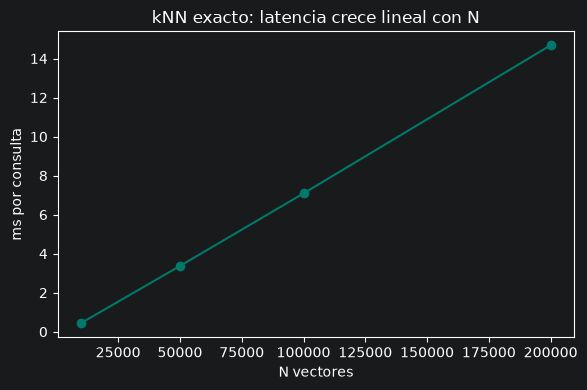

In [2]:
# Ejercicio 1.1 — el costo O(N·d), medido
def knn_exacto(consulta, base, k=10):
    scores = base @ consulta
    return np.argsort(scores)[::-1][:k]

tamanos = [10_000, 50_000, 100_000, 200_000]
tiempos = []
for N in tamanos:
    base = normalizar(datos_realistas(N))
    q = normalizar(datos_realistas(1))[0]
    t0 = time.perf_counter()
    for _ in range(20):
        knn_exacto(q, base)
    ms = (time.perf_counter() - t0) / 20 * 1000
    tiempos.append(ms)
    print(f"N={N:>7,}  →  {ms:6.2f} ms/consulta")

plt.figure(figsize=(6, 4))
plt.plot(tamanos, tiempos, "o-", color="#00796B")
plt.xlabel("N vectores"); plt.ylabel("ms por consulta")
plt.title("kNN exacto: latencia crece lineal con N")
plt.tight_layout(); plt.show()

Lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.

## Parte 2 — Mini-IVF: clustering + búsqueda local

La receta: (1) k-means agrupa la base en `nlist` celdas; (2) en consulta,
comparar solo contra los centroides y buscar exacto dentro de las `nprobe`
celdas más cercanas.

In [3]:
from sklearn.cluster import KMeans

N = 100_000
base = normalizar(datos_realistas(N))
NLIST = 64
km = KMeans(n_clusters=NLIST, n_init=3, random_state=7).fit(base)
centroides = normalizar(km.cluster_centers_.astype(np.float32))
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]
print(f"IVF entrenado: {NLIST} celdas, tamaño medio {np.mean([len(c) for c in celdas]):.0f}")

IVF entrenado: 64 celdas, tamaño medio 1562


In [4]:
# Ejercicio 2.1 — implementa knn_ivf(consulta, nprobe, k):
# 1) scores contra centroides → nprobe celdas más cercanas
# 2) kNN exacto solo dentro de esas celdas (índices globales!)
def knn_ivf(consulta, nprobe=2, k=10):
    top_celdas = np.argsort(centroides @ consulta)[::-1][:nprobe]
    candidatos = np.concatenate([celdas[c] for c in top_celdas])
    scores = base[candidatos] @ consulta
    return candidatos[np.argsort(scores)[::-1][:k]]

In [5]:
# Ejercicio 2.2 — para nprobe = 1, 2, 4, 8, 16 mide:
#   recall@10 (vs. knn_exacto) promedio sobre 50 consultas, y speedup vs. exacto
consultas = normalizar(datos_realistas(50))

t0 = time.perf_counter()
verdad = [set(knn_exacto(q, base)) for q in consultas]
t_exacto = time.perf_counter() - t0

print(f"{'nprobe':>7} {'recall@10':>10} {'speedup':>9}")
resultados = []
for nprobe in (1, 2, 4, 8, 16):
    t0 = time.perf_counter()
    aprox = [set(knn_ivf(q, nprobe)) for q in consultas]
    t_ivf = time.perf_counter() - t0
    recall = np.mean([len(a & v) / 10 for a, v in zip(aprox, verdad)])
    resultados.append((nprobe, recall, t_exacto / t_ivf))
    print(f"{nprobe:>7} {recall:>10.3f} {t_exacto / t_ivf:>8.1f}x")

 nprobe  recall@10   speedup
      1      0.866     22.4x
      2      0.876     12.6x
      4      0.888      6.9x
      8      0.930      3.3x
     16      0.962      1.6x


**La tabla del triángulo recall/latencia:** con `nprobe` pequeño obtienes
speedups grandes pero pierdes vecinos (los de las fronteras entre celdas);
subiendo `nprobe` recuperas recall y pagas latencia. HNSW ofrece el mismo dial
(`ef_search`) con mejor curva — por eso es el default de las vector DBs.

## Parte 3 — Qdrant embebido: una vector DB real sin Docker

In [8]:
faqs = [
    ("Para resetear tu contraseña entra a Configuración > Seguridad.", "cuenta"),
    ("Los reembolsos se procesan en 5 a 7 días hábiles.", "pagos"),
    ("Puedes exportar tus datos en formato CSV desde el panel.", "cuenta"),
    ("La factura electrónica se emite al confirmar el pago.", "pagos"),
    ("El soporte atiende de lunes a viernes de 9h a 18h.", "soporte"),
    ("La API permite 100 solicitudes por minuto en el plan básico.", "api"),
]

try:
    from qdrant_client import QdrantClient
    from qdrant_client.models import Distance, VectorParams, PointStruct, Filter, FieldCondition, MatchValue

    # embeddings sintéticos por documento, reproducibles solo dentro de esta corrida:
    # hash() cambia entre procesos (en el lab: sentence-transformers)
    def embed_demo(texto):
        r = np.random.default_rng(abs(hash(texto)) % (2**32))
        v = r.normal(size=64).astype(np.float32)
        return (v / np.linalg.norm(v)).tolist()

    cliente = QdrantClient("localhost:6333")
    cliente.create_collection("faqs", vectors_config=VectorParams(size=64, distance=Distance.COSINE))
    cliente.upsert("faqs", points=[
        PointStruct(id=i, vector=embed_demo(t), payload={"texto": t, "tema": tema})
        for i, (t, tema) in enumerate(faqs)
    ])
    print("Colección creada con", cliente.count("faqs").count, "puntos")

    # consulta con filtro de metadata: solo tema="pagos"
    hits = cliente.query_points(
        "faqs",
        query=embed_demo("¿cuándo me devuelven el dinero?"),
        query_filter=Filter(must=[FieldCondition(key="tema", match=MatchValue(value="pagos"))]),
        limit=2,
    ).points
    for h in hits:
        print(f"  {h.score:.3f} [{h.payload['tema']}] {h.payload['texto']}")
    print("\n(Nota: con embeddings sintéticos el score no es semántico —")
    print(" el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)")
except ImportError:
    print("qdrant-client no instalado — `pip install qdrant-client` para esta parte.")

Colección creada con 6 puntos
  0.245 [pagos] Los reembolsos se procesan en 5 a 7 días hábiles.
  -0.184 [pagos] La factura electrónica se emite al confirmar el pago.

(Nota: con embeddings sintéticos el score no es semántico —
 el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)


### 🧑‍🏫 Guía de respuestas
a) Con < 100k docs y tráfico de aula, kNN exacto en NumPy ya da < 20 ms:
   ANN es innecesario — el punto es que lo JUSTIFIQUEN con la medición.
b) Cualquier motor bien argumentado vale; penalizar solo "porque es el más famoso".

## Cierre

- kNN exacto: O(N·d), lineal — se mide, no se asume.
- IVF: carpetas + nprobe; HNSW: grafo jerárquico + ef_search. Mismo triángulo:
  recall / latencia / memoria.
- Qdrant: colección → upsert(vector+payload) → query con filtros.

**Mañana:** armamos el pipeline RAG completo — y descubrimos que el chunking
importa más que el índice.